<a href="https://colab.research.google.com/github/MarcelinaBytes/AIHC5020/blob/main/AIHC5020_hw5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 5: Unstructured data**

  Problem 1: Loading and Processing MIT-BIH Data

In [2]:
!pip install -q wfdb

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from google.colab import drive
drive.mount('/content/drive')

#dataset path
WFDB_ROOT = '/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb'

#folder contains record files?
print(os.listdir(WFDB_ROOT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['100.atr', '100.dat', '100.hea', '101.hea', '101.atr', '101.dat', '102.dat', '102.hea', '103.hea', '103.atr', '103.dat', '104.hea', '104.dat', '104.atr', '105.hea', '105.dat', '105.atr', '106.atr', '106.dat', '106.hea', '107.dat', '107.atr', '107.hea', '108.at_', '108.hea', '109.atr', '109.hea', '111.atr', '111.hea', '112.hea', '112.atr', '113.hea', '113.atr', '114.hea', '114.atr', '115.hea', '115.atr', '116.hea', '116.atr', '117.hea', '117.at_', '118.atr', '118.dat', '118.hea', '119.dat', '119.hea', '119.at_', '121.atr', '121.hea', '122.hea', '122.atr', '123.atr', '123.hea', '124.atr', '124.hea', '200.dat', '200.atr', '200.hea', '201.atr', '201.dat', '201.hea', '202.hea', '202.dat', '202.atr', '203.hea', '203.at_', '203.dat', '205.hea', '205.dat', '205.atr', '207.atr', '207.hea', '207.dat', '208.atr', '208.dat', '208.hea', '209.dat', '209.at_', '209.hea', '

In [3]:
def load_ecg_data(record_number: int, max_duration: float, wfdb_root: str):
    """
    Load MIT-BIH ECG + annotations, truncate to max_duration seconds.

    Returns:
        ecg_df, annotations_df, sample_rate
    """

    # uild record path WITHOUT extension
    record_path = os.path.join(wfdb_root, str(record_number))

    #load waveform
    rec = wfdb.rdrecord(record_path)
    fs = float(rec.fs)   # sample rate

    #load annotations
    ann = wfdb.rdann(record_path, extension='atr')

    #compute cutoff in samples
    total_samples = rec.p_signal.shape[0]
    cutoff = int(max_duration * fs)
    cutoff = min(cutoff, total_samples)

    #build ECG DataFrame
    ecg_df = pd.DataFrame(
        data = rec.p_signal[:cutoff, :],
        columns = rec.sig_name
    )

    #build annotations DataFrame
    mask = ann.sample < cutoff
    annotations_df = pd.DataFrame({
        "annotation_index": ann.sample[mask].astype(int),
        "annotation_text": np.asarray(ann.symbol)[mask]
    })

    return ecg_df, annotations_df, fs

In [4]:
ecg_df, annotations_df, fs = load_ecg_data(100, 10, WFDB_ROOT)

print("Sample rate:", fs)
display(ecg_df.tail())
display(annotations_df.tail())

Sample rate: 360.0


,MLII,V5
3595,-0.385,-0.285
3596,-0.395,-0.285
3597,-0.390,-0.295
3598,-0.400,-0.290
3599,-0.405,-0.285


,annotation_index,annotation_text
9,2402,N
10,2706,N
11,2998,N
12,3282,N
13,3560,N


**CHALLENGE CASE**

In [5]:
ecg_101, ann_101, fs_101 = load_ecg_data(101, 15, WFDB_ROOT)

print("Record 101 sample rate:", fs_101)
display(ecg_101.tail())
display(ann_101.tail())

Record 101 sample rate: 360.0


,MLII,V1
5395,-0.275,-0.035
5396,-0.250,-0.015
5397,-0.245,-0.005
5398,-0.245,0.005
5399,-0.250,0.000


,annotation_index,annotation_text
13,3960,N
14,4283,N
15,4609,N
16,4928,N
17,5241,N


  Problem 2: Visualizing ECG Segments and Annotations

In [6]:
def plot_ecg_segment(ecg_df, annotations_df, channel_name, start_index, end_index):
    """
    Plot ECG segment + annotation markers.
    """

    # Validate channel
    if channel_name not in ecg_df.columns:
        raise ValueError(f"Channel {channel_name} not in ECG dataframe.")

    # Clamp indices
    start = max(0, int(start_index))
    end = min(int(end_index), len(ecg_df)-1)

    # Slice signal
    window = ecg_df.loc[start:end, channel_name]

    # Slice annotations in window
    anns = annotations_df[
        (annotations_df["annotation_index"] >= start) &
        (annotations_df["annotation_index"] <= end)
    ]

    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(window.index, window.values, color="black", linewidth=1)

    # Add annotation markers + labels
    y_top = ax.get_ylim()[1]
    for _, row in anns.iterrows():
        x = int(row["annotation_index"])
        ax.axvline(x, color='red', linestyle='--', alpha=0.7)
        ax.text(x, y_top, row["annotation_text"],
                color='red', ha='center', va='top')

    ax.set_title(f"{channel_name} ECG Segment: samples {start}–{end}")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Amplitude (mV)")
    ax.grid(True, linestyle=":")
    plt.show()

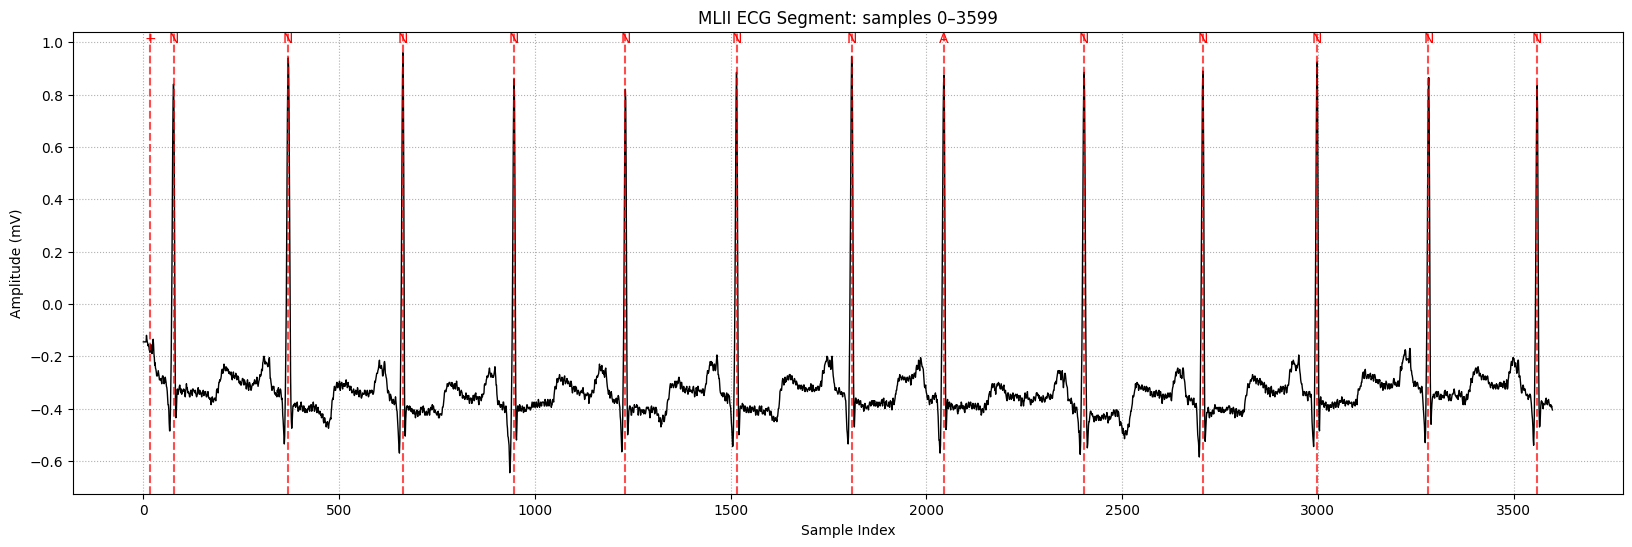

In [7]:
plot_ecg_segment(
    ecg_df,
    annotations_df,
    channel_name="MLII",
    start_index=0,
    end_index=len(ecg_df)-1
)

**CHALLENGE CASE**

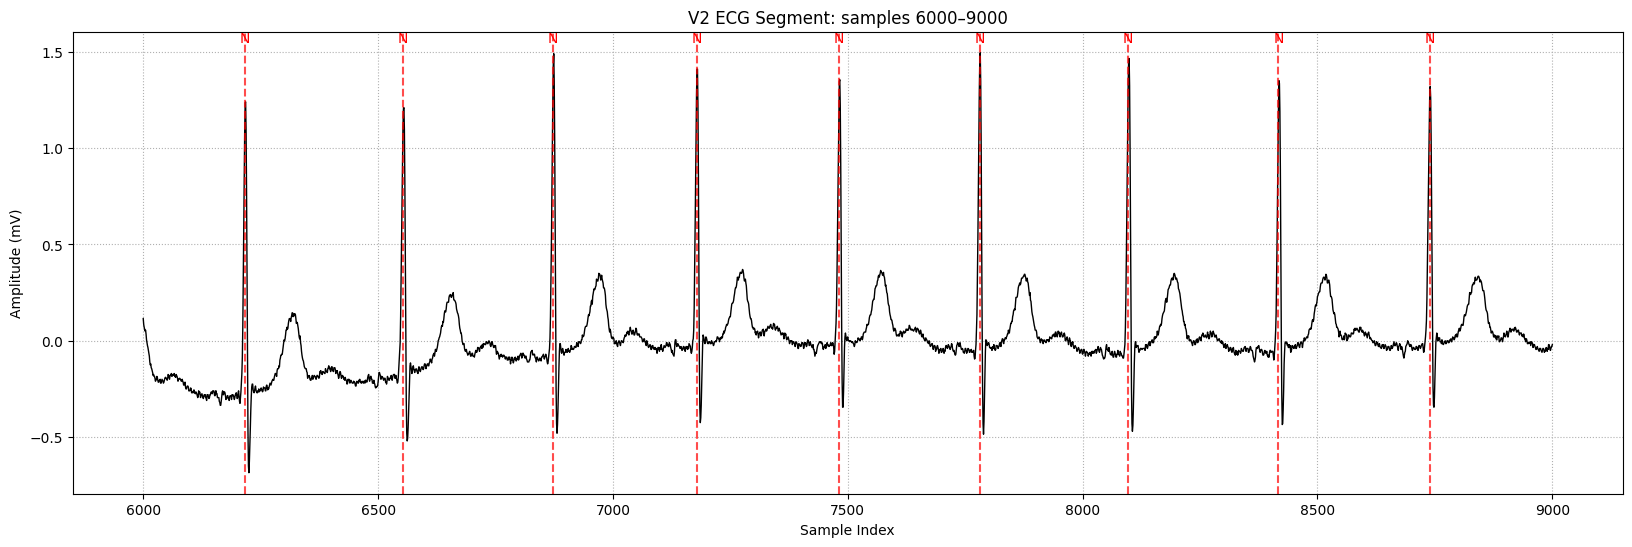

In [8]:
# Load
ecg_103, ann_103, fs_103 = load_ecg_data(103, max_duration=30, wfdb_root=WFDB_ROOT)

# Plot the requested window
plot_ecg_segment(
    ecg_df=ecg_103,
    annotations_df=ann_103,
    channel_name="V2",
    start_index=6000,
    end_index=9000
)

  Problem 3: Segment Table Transformation

In [9]:
import numpy as np
import pandas as pd
import math

def create_segment_table(record_number, max_duration, wfdb_root, segment_duration):
    """
    Create a segment table for one MIT-BIH record.

    Each row = 1 channel × 1 segment.
    """

    #load full ECG
    ecg_df, annotations_df, fs = load_ecg_data(record_number, max_duration, wfdb_root)

    #compute segmentation information
    samples_per_segment = int(segment_duration * fs)
    total_samples = len(ecg_df)

    #number of segments
    n_segments = math.ceil(total_samples / samples_per_segment)

    #build segment start indices
    segment_starts = np.arange(0, n_segments * samples_per_segment, samples_per_segment)

    #construct segment table rows
    rows = []

    for seg_idx, start_idx in enumerate(segment_starts):
        end_idx = min(start_idx + samples_per_segment, total_samples)

        for channel_name in ecg_df.columns:
            segment_values = ecg_df[channel_name].iloc[start_idx:end_idx].values

            rows.append({
                "record_number": record_number,
                "segment_index": seg_idx,
                "sample_rate": fs,
                "n_samples": len(segment_values),
                "channel_name": channel_name,
                "segment_start_index": start_idx,
                "segment": segment_values
            })

    #convert to DataFrame and return
    segment_table = pd.DataFrame(rows)
    return segment_table

In [10]:
seg_table_100 = create_segment_table(
    record_number=100,
    max_duration=30,
    wfdb_root=WFDB_ROOT,
    segment_duration=4
)

seg_table_100.head()

,record_number,segment_index,sample_rate,n_samples,channel_name,segment_start_index,segment
0,100,0,360.0,1440,MLII,0,"[-0.145, -0.145, -0.145, -0.145, -0.145, -0.14..."
1,100,0,360.0,1440,V5,0,"[-0.065, -0.065, -0.065, -0.065, -0.065, -0.06..."
2,100,1,360.0,1440,MLII,1440,"[-0.27, -0.255, -0.26, -0.265, -0.26, -0.25, -..."
3,100,1,360.0,1440,V5,1440,"[-0.26, -0.255, -0.25, -0.255, -0.25, -0.24, -..."
4,100,2,360.0,1440,MLII,2880,"[-0.32, -0.315, -0.33, -0.34, -0.34, -0.35, -0..."


CHALLENGE CASE

In [11]:
seg_table_102 = create_segment_table(
    record_number=102,
    max_duration=30,
    wfdb_root=WFDB_ROOT,
    segment_duration=4
)

seg_table_102.head()

,record_number,segment_index,sample_rate,n_samples,channel_name,segment_start_index,segment
0,102,0,360.0,1440,V5,0,"[-0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0...."
1,102,0,360.0,1440,V2,0,"[0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.0..."
2,102,1,360.0,1440,V5,1440,"[-0.15, -0.155, -0.15, -0.165, -0.175, -0.165,..."
3,102,1,360.0,1440,V2,1440,"[0.705, 0.635, 0.565, 0.505, 0.465, 0.43, 0.38..."
4,102,2,360.0,1440,V5,2880,"[-0.225, -0.215, -0.205, -0.21, -0.21, -0.2, -..."


  Problem 4: Creating a DICOM Series Manifest

In [12]:
!pip install -q pydicom

import os
from pathlib import Path
import pydicom
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.6 MB/s eta 0:00:00


In [13]:
LIDC_ROOT = "/content/drive/MyDrive/AIHC5020/dicom/tcia/LIDC-IDRI"

In [28]:
from typing import List, Dict

def create_dicom_manifest(root_dir: str) -> pd.DataFrame:
    root = Path(root_dir)
    rows: List[Dict] = []

    # Walk the tree
    for dirpath, dirnames, filenames in os.walk(root):
        p = Path(dirpath)

        #identify series folders
        dcm_files = [f for f in filenames if f.lower().endswith(".dcm")]
        if not dcm_files:
            continue  # not a series folder

        # Count all .dcm files in this folder
        n_images = len(dcm_files)

        # Read ONE sample .dcm to get metadata
        sample_path = p / dcm_files[0]
        try:
            ds = pydicom.dcmread(str(sample_path), stop_before_pixels=True)
        except Exception as e:
            # Skip problem folder
            print(f"[WARN] Could not read {sample_path}: {e}")
            continue

        # Safely extract tags
        patient_id = getattr(ds, "PatientID", "N/A")
        study_date  = getattr(ds, "StudyDate", "N/A")
        modality    = getattr(ds, "Modality", "N/A")
        study_desc  = ds.get("StudyDescription", "N/A")
        series_desc = ds.get("SeriesDescription", "N/A")
        study_uid   = getattr(ds, "StudyInstanceUID", "N/A")
        series_uid  = getattr(ds, "SeriesInstanceUID", "N/A")

        rows.append({
            "patient_id": patient_id,
            "study_date": study_date,
            "modality": modality,
            "study_description": study_desc,
            "series_description": series_desc,
            "n_images": n_images,
            "study_instance_uid": study_uid,
            "series_instance_uid": series_uid,
            "series_path": str(p.resolve())
        })

    # Convert to DataFrame
    manifest = pd.DataFrame(rows)

    # sort for readability
    if not manifest.empty:
        manifest = manifest.sort_values(
            by=["patient_id", "study_date", "modality", "series_description"],
            kind="stable"
        ).reset_index(drop=True)

    return manifest


In [29]:
manifest = create_dicom_manifest(LIDC_ROOT)
manifest.head()
manifest.shape  # (rows, columns)

(92, 9)

In [30]:
ct_manifest = manifest[manifest["modality"] == "CT"].copy()
ct_manifest


,patient_id,study_date,modality,study_description,series_description,n_images,study_instance_uid,series_instance_uid,series_path
0,LIDC-IDRI-0001,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,/content/drive/.shortcut-targets-by-id/1LsGJik...
10,LIDC-IDRI-0002,20000101,CT,N/A,N/A,261,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,/content/drive/.shortcut-targets-by-id/1LsGJik...
16,LIDC-IDRI-0003,20000101,CT,N/A,N/A,140,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,/content/drive/.shortcut-targets-by-id/1LsGJik...
45,LIDC-IDRI-0004,20000101,CT,N/A,N/A,241,1.3.6.1.4.1.14519.5.2.1.6279.6001.191425307197...,1.3.6.1.4.1.14519.5.2.1.6279.6001.323541312620...,/content/drive/.shortcut-targets-by-id/1LsGJik...
54,LIDC-IDRI-0005,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,/content/drive/.shortcut-targets-by-id/1LsGJik...
74,LIDC-IDRI-0006,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...,1.3.6.1.4.1.14519.5.2.1.6279.6001.132817748896...,/content/drive/.shortcut-targets-by-id/1LsGJik...


  Problem 5: Visualizing DICOM slices

In [21]:
import os
from pathlib import Path
from typing import List, Tuple
import numpy as np
import pydicom
import matplotlib.pyplot as plt

def _collect_dcm_sorted_by_instance(series_dir: Path) -> List[Tuple[int, Path]]:
    """
    Return a list of (instance_number, path) for every .dcm in the series,
    sorted by instance_number (fallback to 0 if missing).
    """
    dcm_paths = [p for p in series_dir.iterdir() if p.suffix.lower() == ".dcm"]
    info: List[Tuple[int, Path]] = []
    for p in dcm_paths:
        try:
            ds = pydicom.dcmread(str(p), stop_before_pixels=True)
            inst = int(getattr(ds, "InstanceNumber", 0))
        except Exception:
            inst = 0
        info.append((inst, p))
    info.sort(key=lambda t: t[0])
    return info

def _evenly_spaced_indices(n: int, k: int = 4) -> List[int]:
    """
    Choose ~k evenly spaced indices in [0, n-1].
    Uses quantiles at 0.2, 0.4, 0.6, 0.8 when n >= k;
    if n < k, returns range(n).
    """
    if n <= 0:
        return []
    if n <= k:
        return list(range(n))
    quantiles = [0.2, 0.4, 0.6, 0.8]
    idxs = {min(n - 1, max(0, int(round(q * (n - 1))))) for q in quantiles}
    return sorted(idxs)

def _window_image(img_hu: np.ndarray, center: float = -600.0, width: float = 1500.0) -> np.ndarray:
    """
    Simple linear windowing for CT (default: lung window).
    Returns a float image normalized to [0, 1].
    """
    low, high = center - width / 2.0, center + width / 2.0


In [22]:
'visualize_ct_series' in globals()

False

In [23]:
[x for x in globals().keys() if 'visual' in x.lower()]

[]

In [24]:
import os
from pathlib import Path
from typing import List, Tuple
import numpy as np
import pydicom
import matplotlib.pyplot as plt

def _collect_dcm_sorted_by_instance(series_dir: Path) -> List[Tuple[int, Path]]:
    dcm_paths = [p for p in Path(series_dir).iterdir() if p.suffix.lower() == ".dcm"]
    info = []
    for p in dcm_paths:
        try:
            ds = pydicom.dcmread(str(p), stop_before_pixels=True)
            inst = int(getattr(ds, "InstanceNumber", 0))
        except:
            inst = 0
        info.append((inst, p))
    info.sort(key=lambda x: x[0])
    return info

def _evenly_spaced_indices(n, k=4):
    if n <= k:
        return list(range(n))
    qs = [0.2, 0.4, 0.6, 0.8]
    idxs = [int(round(q * (n-1))) for q in qs]
    return sorted(set(idxs))

def _window_image(img_hu, center=-600.0, width=1500.0):
    low, high = center - width/2, center + width/2
    img = np.clip(img_hu, low, high)
    return (img - low) / (high - low + 1e-9)

def visualize_ct_series(manifest_row):
    modality = str(manifest_row.get("modality", "")).upper()
    if modality != "CT":
        raise ValueError("This function only works for CT series.")
    if int(manifest_row.get("n_images", 0)) <= 1:
        raise ValueError("CT series must contain multiple slices.")

    series_dir = Path(manifest_row["series_path"])
    slices = _collect_dcm_sorted_by_instance(series_dir)
    n = len(slices)
    pick_idxs = _evenly_spaced_indices(n, 4)

    images = []
    labels = []

    for idx in pick_idxs:
        inst_num, fpath = slices[idx]
        ds = pydicom.dcmread(str(fpath))
        arr = ds.pixel_array.astype(np.int16)
        slope = float(getattr(ds, "RescaleSlope", 1))
        intercept = float(getattr(ds, "RescaleIntercept", 0))
        hu = arr * slope + intercept
        display_img = _window_image(hu)
        images.append(display_img)
        labels.append(f"Slice {inst_num}")

    fig, axs = plt.subplots(1, len(images), figsize=(16, 4))
    if len(images) == 1:
        axs = [axs]
    for ax, img, lbl in zip(axs, images, labels):
        ax.imshow(img, cmap='gray')
        ax.set_title(lbl)
        ax.set_axis_off()

    pid = manifest_row.get("patient_id", "Unknown")
    date = manifest_row.get("study_date", "Unknown")
    fig.suptitle(f"Patient {pid}  Study {date}  |  CT Series", fontsize=14)

    plt.tight_layout()
    plt.show()


In [25]:
'visualize_ct_series' in globals()

True

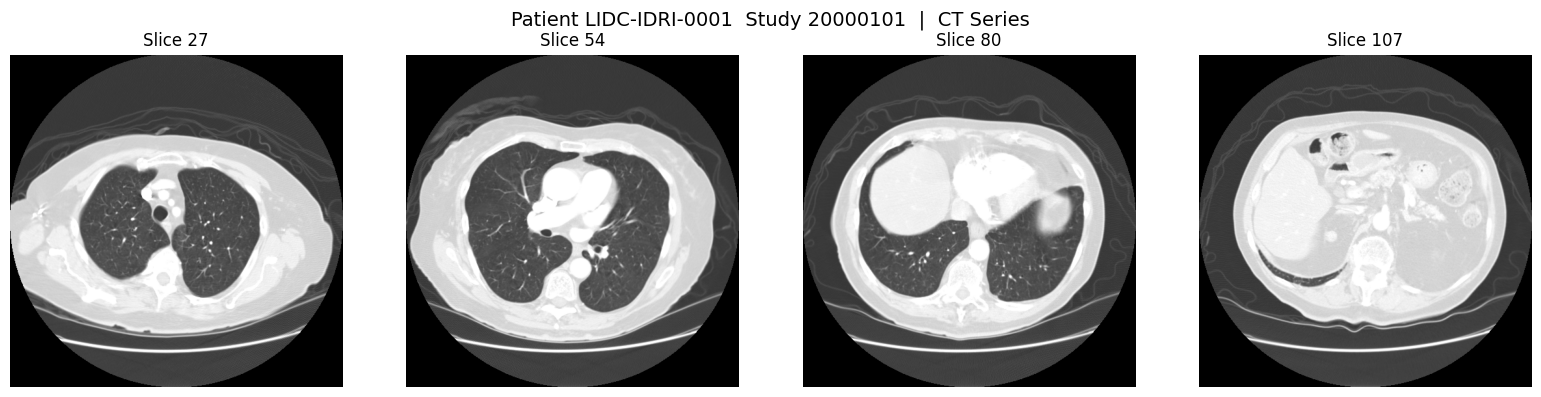

In [26]:
ct_rows = manifest[manifest["modality"] == "CT"].reset_index(drop=True)
visualize_ct_series(ct_rows.iloc[0])